## Preprocessing Precinct Boundaries

In [1]:
import pandas as pd
import pygris
import geopandas
import topojson as tp
import json

### Arkansas Precinct Boundary Path

#### CVAP Census Data Estimates

In [2]:
path = '../../data/Arkansas/ar-cb-CVAP.csv'

In [3]:
cb_df = pd.read_csv(path)
cb_df

,geoname,lntitle,geoid,lnnumber,cit_est,cit_moe,cvap_est,cvap_moe
0,"Block Group 1, Census Tract 201, Autauga Count...",Total,1500000US010010201001,1,486,149,409,103
1,"Block Group 1, Census Tract 201, Autauga Count...",Not Hispanic or Latino,1500000US010010201001,2,444,131,391,106
2,"Block Group 1, Census Tract 201, Autauga Count...",American Indian or Alaska Native Alone,1500000US010010201001,3,0,13,0,13
3,"Block Group 1, Census Tract 201, Autauga Count...",Asian Alone,1500000US010010201001,4,0,13,0,13
4,"Block Group 1, Census Tract 201, Autauga Count...",Black or African American Alone,1500000US010010201001,5,7,6,0,13
...,...,...,...,...,...,...,...,...
3149856,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Asian and White,1500000US721537506022,9,0,15,0,15
3149857,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Black or African American and White,1500000US721537506022,10,0,15,0,15
3149858,"Block Group 2, Census Tract 7506.02, Yauco Mun...",American Indian or Alaska Native and Black or ...,1500000US721537506022,11,0,15,0,15
3149859,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Remainder of Two or More Race Responses,1500000US721537506022,12,0,15,0,15


In [4]:
cb_df = cb_df[['geoname', 'lntitle', 'geoid', 'cvap_est']]
cb_df

,geoname,lntitle,geoid,cvap_est
0,"Block Group 1, Census Tract 201, Autauga Count...",Total,1500000US010010201001,409
1,"Block Group 1, Census Tract 201, Autauga Count...",Not Hispanic or Latino,1500000US010010201001,391
2,"Block Group 1, Census Tract 201, Autauga Count...",American Indian or Alaska Native Alone,1500000US010010201001,0
3,"Block Group 1, Census Tract 201, Autauga Count...",Asian Alone,1500000US010010201001,0
4,"Block Group 1, Census Tract 201, Autauga Count...",Black or African American Alone,1500000US010010201001,0
...,...,...,...,...
3149856,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Asian and White,1500000US721537506022,0
3149857,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Black or African American and White,1500000US721537506022,0
3149858,"Block Group 2, Census Tract 7506.02, Yauco Mun...",American Indian or Alaska Native and Black or ...,1500000US721537506022,0
3149859,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Remainder of Two or More Race Responses,1500000US721537506022,0


In [5]:
relevant_groups = ['Total', 'Black or African American Alone', 'White Alone', 'Hispanic or Latino']
cb_df = cb_df[cb_df['lntitle'].isin(relevant_groups)]
cb_df

,geoname,lntitle,geoid,cvap_est
0,"Block Group 1, Census Tract 201, Autauga Count...",Total,1500000US010010201001,409
4,"Block Group 1, Census Tract 201, Autauga Count...",Black or African American Alone,1500000US010010201001,0
6,"Block Group 1, Census Tract 201, Autauga Count...",White Alone,1500000US010010201001,358
12,"Block Group 1, Census Tract 201, Autauga Count...",Hispanic or Latino,1500000US010010201001,18
13,"Block Group 2, Census Tract 201, Autauga Count...",Total,1500000US010010201002,909
...,...,...,...,...
3149847,"Block Group 1, Census Tract 7506.02, Yauco Mun...",Hispanic or Latino,1500000US721537506021,1081
3149848,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Total,1500000US721537506022,771
3149852,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Black or African American Alone,1500000US721537506022,0
3149854,"Block Group 2, Census Tract 7506.02, Yauco Mun...",White Alone,1500000US721537506022,0


In [6]:
grouped = (
    cb_df[cb_df['lntitle'] != 'Total']
    .groupby(['geoid', 'geoname'])['cvap_est']
    .sum()
    .reset_index()
)

totals = cb_df[cb_df['lntitle'] == 'Total'][['geoid', 'geoname', 'cvap_est']]

merged = totals.merge(
    grouped,
    on=['geoid', 'geoname'],
    suffixes=('_Total', '_Known')
)

merged['Other'] = merged['cvap_est_Total'] - merged['cvap_est_Known']

other_rows = merged[['geoid', 'geoname', 'Other']].rename(columns={'Other': 'cvap_est'})
other_rows['lntitle'] = 'Other'

cb_df = pd.concat(
    [cb_df, other_rows[['geoid', 'geoname', 'lntitle', 'cvap_est']]],
    ignore_index=True
)

cb_df

,geoname,lntitle,geoid,cvap_est
0,"Block Group 1, Census Tract 201, Autauga Count...",Total,1500000US010010201001,409
1,"Block Group 1, Census Tract 201, Autauga Count...",Black or African American Alone,1500000US010010201001,0
2,"Block Group 1, Census Tract 201, Autauga Count...",White Alone,1500000US010010201001,358
3,"Block Group 1, Census Tract 201, Autauga Count...",Hispanic or Latino,1500000US010010201001,18
4,"Block Group 2, Census Tract 201, Autauga Count...",Total,1500000US010010201002,909
...,...,...,...,...
1211480,"Block Group 1, Census Tract 7506.01, Yauco Mun...",Other,1500000US721537506011,0
1211481,"Block Group 2, Census Tract 7506.01, Yauco Mun...",Other,1500000US721537506012,0
1211482,"Block Group 3, Census Tract 7506.01, Yauco Mun...",Other,1500000US721537506013,0
1211483,"Block Group 1, Census Tract 7506.02, Yauco Mun...",Other,1500000US721537506021,0


In [7]:
cb_df = cb_df.sort_values(by='geoname')
cb_df

,geoname,lntitle,geoid,cvap_est
566151,"Block Group 0, Census Tract 1, Bronx County, N...",Hispanic or Latino,1500000US360050001000,0
566148,"Block Group 0, Census Tract 1, Bronx County, N...",Total,1500000US360050001000,0
566149,"Block Group 0, Census Tract 1, Bronx County, N...",Black or African American Alone,1500000US360050001000,0
566150,"Block Group 0, Census Tract 1, Bronx County, N...",White Alone,1500000US360050001000,0
1110725,"Block Group 0, Census Tract 1, Bronx County, N...",Other,1500000US360050001000,0
...,...,...,...,...
383191,"Block Group 9, Census Tract 9618.01, St. Landr...",Hispanic or Latino,1500000US220979618019,25
383188,"Block Group 9, Census Tract 9618.01, St. Landr...",Total,1500000US220979618019,169
1064985,"Block Group 9, Census Tract 9618.01, St. Landr...",Other,1500000US220979618019,0
383190,"Block Group 9, Census Tract 9618.01, St. Landr...",White Alone,1500000US220979618019,144


##### Only Arkansas

In [8]:
ar_cb = cb_df[cb_df['geoname'].str.endswith('Arkansas')]
ar_cb

,geoname,lntitle,geoid,cvap_est
44258,"Block Group 1, Census Tract 1, Sebastian Count...",White Alone,1500000US051310001001,128
44257,"Block Group 1, Census Tract 1, Sebastian Count...",Black or African American Alone,1500000US051310001001,233
44259,"Block Group 1, Census Tract 1, Sebastian Count...",Hispanic or Latino,1500000US051310001001,155
44256,"Block Group 1, Census Tract 1, Sebastian Count...",Total,1500000US051310001001,593
980252,"Block Group 1, Census Tract 1, Sebastian Count...",Other,1500000US051310001001,77
...,...,...,...,...
978791,"Block Group 7, Census Tract 3, Craighead Count...",Other,1500000US050310003007,7
38415,"Block Group 7, Census Tract 3, Craighead Count...",Hispanic or Latino,1500000US050310003007,0
38412,"Block Group 7, Census Tract 3, Craighead Count...",Total,1500000US050310003007,924
38413,"Block Group 7, Census Tract 3, Craighead Count...",Black or African American Alone,1500000US050310003007,0


In [9]:
ar_cb.drop(columns='geoname', inplace=True)
ar_cb

,lntitle,geoid,cvap_est
44258,White Alone,1500000US051310001001,128
44257,Black or African American Alone,1500000US051310001001,233
44259,Hispanic or Latino,1500000US051310001001,155
44256,Total,1500000US051310001001,593
980252,Other,1500000US051310001001,77
...,...,...,...
978791,Other,1500000US050310003007,7
38415,Hispanic or Latino,1500000US050310003007,0
38412,Total,1500000US050310003007,924
38413,Black or African American Alone,1500000US050310003007,0


In [10]:
ar_cb['county_fips'] = ar_cb['geoid'].str.extract(r'1500000US(\d{5})')
ar_cb

,lntitle,geoid,cvap_est,county_fips
44258,White Alone,1500000US051310001001,128,05131
44257,Black or African American Alone,1500000US051310001001,233,05131
44259,Hispanic or Latino,1500000US051310001001,155,05131
44256,Total,1500000US051310001001,593,05131
980252,Other,1500000US051310001001,77,05131
...,...,...,...,...
978791,Other,1500000US050310003007,7,05031
38415,Hispanic or Latino,1500000US050310003007,0,05031
38412,Total,1500000US050310003007,924,05031
38413,Black or African American Alone,1500000US050310003007,0,05031


In [11]:
ar_cb = ar_cb.sort_values(by=['county_fips', 'geoid'])
ar_cb

,lntitle,geoid,cvap_est,county_fips
36811,Hispanic or Latino,1500000US050014801001,0,05001
36809,Black or African American Alone,1500000US050014801001,98,05001
978390,Other,1500000US050014801001,20,05001
36808,Total,1500000US050014801001,811,05001
36810,White Alone,1500000US050014801001,693,05001
...,...,...,...,...
45983,Hispanic or Latino,1500000US051499526003,19,05149
45982,White Alone,1500000US051499526003,774,05149
980683,Other,1500000US051499526003,0,05149
45980,Total,1500000US051499526003,793,05149


#### NYT Precinct Election Data

In [12]:
nyt_path = '../../data/Arkansas/nyt-ar-precinct.geojson'

In [13]:
nyt_gdf = geopandas.read_file(nyt_path)
nyt_gdf

,state,GEOID,votes_dem,votes_rep,votes_total,pct_dem_lead,official_boundary,geometry
0,AR,05001-81 - Stuttgart 2,293,639,951,-0.3638,True,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,AR,05001-36 - Gillett Ward 3,25,39,66,-0.2121,True,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,AR,05001-53 - Dewitt 2,49,188,242,-0.5744,True,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,AR,05001-51 - DeWitt 1,101,61,167,0.2395,True,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,AR,05001-55 - Dewitt 3,42,272,317,-0.7256,True,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...,...
2676,AR,05149-10 - Dardanelle Ward 3,59,93,157,-0.2166,True,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,AR,05149-18 - Magazine 1,79,354,440,-0.6250,True,"POLYGON ((-93.27993 35.21256, -93.2806 35.2125..."
2678,AR,05149-29 - Ions Creek,0,19,19,-1.0000,True,"POLYGON ((-93.70875 34.83304, -93.70875 34.833..."
2679,AR,05149-24 - Waveland,18,69,88,-0.5795,True,"POLYGON ((-93.59987 35.14713, -93.60034 35.147..."


In [14]:
nyt_gdf['GEOID'].nunique()

2681

In [15]:
nyt_gdf = nyt_gdf[['state', 'GEOID', 'votes_dem', 'votes_rep', 'votes_total', 'geometry']]
nyt_gdf

,state,GEOID,votes_dem,votes_rep,votes_total,geometry
0,AR,05001-81 - Stuttgart 2,293,639,951,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,AR,05001-36 - Gillett Ward 3,25,39,66,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,AR,05001-53 - Dewitt 2,49,188,242,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,AR,05001-51 - DeWitt 1,101,61,167,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,AR,05001-55 - Dewitt 3,42,272,317,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...
2676,AR,05149-10 - Dardanelle Ward 3,59,93,157,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,AR,05149-18 - Magazine 1,79,354,440,"POLYGON ((-93.27993 35.21256, -93.2806 35.2125..."
2678,AR,05149-29 - Ions Creek,0,19,19,"POLYGON ((-93.70875 34.83304, -93.70875 34.833..."
2679,AR,05149-24 - Waveland,18,69,88,"POLYGON ((-93.59987 35.14713, -93.60034 35.147..."


In [16]:
nyt_gdf['county_fips'] = nyt_gdf['GEOID'].str.extract(r'(\d{5})')
nyt_gdf

,state,GEOID,votes_dem,votes_rep,votes_total,geometry,county_fips
0,AR,05001-81 - Stuttgart 2,293,639,951,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ...",05001
1,AR,05001-36 - Gillett Ward 3,25,39,66,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131...",05001
2,AR,05001-53 - Dewitt 2,49,188,242,"POLYGON ((-91.32906 34.28234, -91.32906 34.282...",05001
3,AR,05001-51 - DeWitt 1,101,61,167,"POLYGON ((-91.32906 34.28234, -91.329 34.28234...",05001
4,AR,05001-55 - Dewitt 3,42,272,317,"POLYGON ((-91.34062 34.30203, -91.34062 34.302...",05001
...,...,...,...,...,...,...,...
2676,AR,05149-10 - Dardanelle Ward 3,59,93,157,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126...",05149
2677,AR,05149-18 - Magazine 1,79,354,440,"POLYGON ((-93.27993 35.21256, -93.2806 35.2125...",05149
2678,AR,05149-29 - Ions Creek,0,19,19,"POLYGON ((-93.70875 34.83304, -93.70875 34.833...",05149
2679,AR,05149-24 - Waveland,18,69,88,"POLYGON ((-93.59987 35.14713, -93.60034 35.147...",05149


#### Merge

In [17]:
nyt_df = nyt_gdf
cvap_df = ar_cb

In [18]:
cvap_df["bg_geoid"] = cvap_df["geoid"].str.replace("1500000US", "")
cvap_df

,lntitle,geoid,cvap_est,county_fips,bg_geoid
36811,Hispanic or Latino,1500000US050014801001,0,05001,050014801001
36809,Black or African American Alone,1500000US050014801001,98,05001,050014801001
978390,Other,1500000US050014801001,20,05001,050014801001
36808,Total,1500000US050014801001,811,05001,050014801001
36810,White Alone,1500000US050014801001,693,05001,050014801001
...,...,...,...,...,...
45983,Hispanic or Latino,1500000US051499526003,19,05149,051499526003
45982,White Alone,1500000US051499526003,774,05149,051499526003
980683,Other,1500000US051499526003,0,05149,051499526003
45980,Total,1500000US051499526003,793,05149,051499526003


In [19]:
cvap_df['geoid']

36811     1500000US050014801001
36809     1500000US050014801001
978390    1500000US050014801001
36808     1500000US050014801001
36810     1500000US050014801001
                  ...          
45983     1500000US051499526003
45982     1500000US051499526003
980683    1500000US051499526003
45980     1500000US051499526003
45981     1500000US051499526003
Name: geoid, Length: 11470, dtype: str

In [20]:
race_map = {
    "Total"                              : "cvap_total",
    "White Alone"                        : "cvap_white",
    "Black or African American Alone"    : "cvap_black",
    "Hispanic or Latino"                 : "cvap_hispanic",
    "Other"                              : "cvap_other",
}

cvap_filtered = cvap_df[cvap_df["lntitle"].isin(race_map)].copy()
cvap_filtered["lntitle"] = cvap_filtered["lntitle"].map(race_map)
cvap_filtered

,lntitle,geoid,cvap_est,county_fips,bg_geoid
36811,cvap_hispanic,1500000US050014801001,0,05001,050014801001
36809,cvap_black,1500000US050014801001,98,05001,050014801001
978390,cvap_other,1500000US050014801001,20,05001,050014801001
36808,cvap_total,1500000US050014801001,811,05001,050014801001
36810,cvap_white,1500000US050014801001,693,05001,050014801001
...,...,...,...,...,...
45983,cvap_hispanic,1500000US051499526003,19,05149,051499526003
45982,cvap_white,1500000US051499526003,774,05149,051499526003
980683,cvap_other,1500000US051499526003,0,05149,051499526003
45980,cvap_total,1500000US051499526003,793,05149,051499526003


In [21]:
cvap_wide = (
    cvap_filtered
    .pivot_table(index="bg_geoid", columns="lntitle", values="cvap_est", aggfunc="sum")
    .reset_index()
)
cvap_wide.columns.name = None
cvap_wide

,bg_geoid,cvap_black,cvap_hispanic,cvap_other,cvap_total,cvap_white
0,050014801001,98,0,20,811,693
1,050014802001,46,61,7,1153,1039
2,050014803001,362,7,0,656,287
3,050014803002,180,0,10,1343,1153
4,050014804001,772,0,45,999,182
...,...,...,...,...,...,...
2289,051499525003,5,54,13,480,408
2290,051499525004,0,22,0,785,763
2291,051499526001,0,22,6,613,585
2292,051499526002,7,6,36,418,369


In [22]:
bg = pygris.block_groups(state='AR', year=2020)
bg = bg[["GEOID", "geometry"]].copy()        

bg = bg.merge(cvap_wide, left_on="GEOID", right_on="bg_geoid", how="left")
bg

Using FIPS code '05' for input 'AR'


,GEOID,geometry,bg_geoid,cvap_black,cvap_hispanic,cvap_other,cvap_total,cvap_white
0,050310011011,"POLYGON ((-90.64716 35.91775, -90.64714 35.917...",050310011011,0,9,34,1811,1768
1,050310011022,"POLYGON ((-90.58719 35.9297, -90.58694 35.9301...",050310011022,0,0,30,574,544
2,050310011021,"POLYGON ((-90.56687 35.87831, -90.56416 35.878...",050310011021,0,0,0,523,523
3,050310004041,"POLYGON ((-90.68694 35.78915, -90.68646 35.789...",050310004041,517,202,85,2223,1419
4,050310004031,"POLYGON ((-90.7027 35.82138, -90.70236 35.8213...",050310004031,35,0,52,1096,1009
...,...,...,...,...,...,...,...,...
2289,050634901023,"POLYGON ((-91.66623 35.8463, -91.66618 35.8463...",050634901023,0,24,24,748,700
2290,050634901021,"POLYGON ((-91.59292 35.8246, -91.59276 35.8249...",050634901021,0,32,10,1046,1004
2291,050634903005,"POLYGON ((-91.64259 35.78524, -91.64253 35.785...",050634903005,0,32,55,589,502
2292,050070205031,"POLYGON ((-94.19751 36.33631, -94.19749 36.337...",050070205031,14,134,67,629,414


In [23]:
CRS  = "EPSG:5070"
nyt_df = nyt_df.to_crs(CRS)
bg     = bg.to_crs(CRS)
bg["bg_area"] = bg.geometry.area
bg

,GEOID,geometry,bg_geoid,cvap_black,cvap_hispanic,cvap_other,cvap_total,cvap_white,bg_area
0,050310011011,"POLYGON ((478484.401 1443006.021, 478484.991 1...",050310011011,0,9,34,1811,1768,3.538900e+07
1,050310011022,"POLYGON ((483763.459 1444645.849, 483782.374 1...",050310011022,0,0,30,574,544,4.280844e+07
2,050310011021,"POLYGON ((485906.083 1439004.702, 486148.893 1...",050310011021,0,0,0,523,523,1.295968e+08
3,050310004041,"POLYGON ((475736.798 1428430.347, 475779.66 14...",050310004041,517,202,85,2223,1419,2.272702e+06
4,050310004031,"POLYGON ((474125.886 1431954.294, 474156.579 1...",050310004031,35,0,52,1096,1009,4.406510e+06
...,...,...,...,...,...,...,...,...,...
2289,050634901023,"POLYGON ((387826.451 1430371.611, 387831.117 1...",050634901023,0,24,24,748,700,9.754002e+07
2290,050634901021,"POLYGON ((394494.557 1428245.624, 394507.71 14...",050634901021,0,32,10,1046,1004,1.493890e+08
2291,050634903005,"POLYGON ((390253.711 1423638.245, 390257.691 1...",050634903005,0,32,55,589,502,2.289376e+07
2292,050070205031,"POLYGON ((160309.362 1477923.184, 160309.137 1...",050070205031,14,134,67,629,414,2.028215e+06


In [24]:
intersected = geopandas.overlay(nyt_df, bg, how="intersection")
intersected["intersect_area"] = intersected.geometry.area
intersected["bg_area"] = intersected.groupby("GEOID_2")["intersect_area"].transform("sum")

intersected["bg_vote_total"] = (
    intersected.groupby("GEOID_2")["votes_total"].transform("sum")
)

intersected["vote_weight"] = (
    intersected["votes_total"] / intersected["bg_vote_total"]
)

intersected["area_weight"] = intersected["intersect_area"] / intersected["bg_area"]

intersected["weight"] = intersected["vote_weight"].where(
    intersected["bg_vote_total"] > 0,
    other=intersected["area_weight"]
)

c:\Users\leeh1\Rockies-Gerrymandering\repo\rockies\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 126 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [25]:
intersected

,state,GEOID_1,votes_dem,votes_rep,votes_total,county_fips,GEOID_2,bg_geoid,cvap_black,cvap_hispanic,cvap_other,cvap_total,cvap_white,bg_area,geometry,intersect_area,bg_vote_total,vote_weight,area_weight,weight
0,AR,05001-81 - Stuttgart 2,293,639,951,05001,050014802001,050014802001,46,61,7,1153,1039,7.508326e+08,"POLYGON ((406041.145 1276426.972, 406041.27 12...",2.345011e+03,3460,0.274855,0.000003,0.274855
1,AR,05001-81 - Stuttgart 2,293,639,951,05001,050014805003,050014805003,133,32,0,520,355,1.013513e+07,"MULTIPOLYGON (((405416.651 1276590.842, 405415...",1.888526e+06,2226,0.427224,0.186335,0.427224
2,AR,05001-81 - Stuttgart 2,293,639,951,05001,050014805002,050014805002,452,68,0,1115,595,1.934910e+06,"POLYGON ((405076.46 1278674.902, 405075.914 12...",6.728342e+05,2478,0.383777,0.347734,0.383777
3,AR,05001-81 - Stuttgart 2,293,639,951,05001,050014803002,050014803002,180,0,10,1343,1153,4.407445e+07,"POLYGON ((406526.356 1280517.108, 406527.56 12...",3.256801e+06,1908,0.498428,0.073893,0.498428
4,AR,05001-81 - Stuttgart 2,293,639,951,05001,050014803001,050014803001,362,7,0,656,287,1.382265e+06,"MULTIPOLYGON (((406352.133 1280514.624, 406380...",6.160844e+05,1534,0.619948,0.445706,0.619948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13319,AR,05149-07 - Dardanelle Outside,246,1140,1412,05149,051499523022,051499523022,0,0,0,395,395,2.441323e+06,"POLYGON ((257336.308 1355692.249, 257410.267 1...",9.062941e+05,2230,0.633184,0.371231,0.633184
13320,AR,05149-07 - Dardanelle Outside,246,1140,1412,05149,051499524021,051499524021,0,159,25,1162,978,1.989119e+08,"POLYGON ((250396.472 1351659.397, 250380.683 1...",3.435278e+07,3352,0.421241,0.172704,0.421241
13321,AR,05149-07 - Dardanelle Outside,246,1140,1412,05149,051499523021,051499523021,59,431,15,1450,945,2.737244e+07,"MULTIPOLYGON (((255223.388 1358450.774, 255223...",2.222888e+07,3735,0.378046,0.812090,0.378046
13322,AR,05149-07 - Dardanelle Outside,246,1140,1412,05149,051159512023,051159512023,0,242,45,1625,1338,4.475846e+07,"MULTIPOLYGON (((263759.302 1347760.223, 263760...",8.098730e+01,4961,0.284620,0.000002,0.284620


In [26]:
cvap_cols = [c for c in intersected.columns if c.startswith("cvap_")]

for col in cvap_cols:
    intersected[col] = intersected[col] * intersected["weight"]

In [27]:
precinct_cvap = (
    intersected
    .groupby("GEOID_1")[cvap_cols]
    .sum()
    .reset_index()
)

precinct_cvap[cvap_cols] = precinct_cvap[cvap_cols].round(0).astype(int)

In [28]:
for col in [c for c in cvap_cols if c != "cvap_total"]:
    precinct_cvap[f"share_{col.replace('cvap_', '')}"] = (
        precinct_cvap[col] / precinct_cvap["cvap_total"]
    )

In [29]:
nyt_final = nyt_df.merge(precinct_cvap, left_on="GEOID", right_on="GEOID_1", how="left")

In [30]:
nyt_final

,state,GEOID,votes_dem,votes_rep,votes_total,geometry,county_fips,GEOID_1,cvap_black,cvap_hispanic,cvap_other,cvap_total,cvap_white,share_black,share_hispanic,share_other,share_white
0,AR,05001-81 - Stuttgart 2,293,639,951,"MULTIPOLYGON (((407828.873 1278111.062, 407829...",05001,05001-81 - Stuttgart 2,557,61,7,2043,1418,0.272638,0.029858,0.003426,0.694077
1,AR,05001-36 - Gillett Ward 3,25,39,66,"POLYGON ((421968.883 1238201.552, 421978.504 1...",05001,05001-36 - Gillett Ward 3,10,1,2,94,80,0.106383,0.010638,0.021277,0.851064
2,AR,05001-53 - Dewitt 2,49,188,242,"POLYGON ((426573.491 1257020.745, 426573.472 1...",05001,05001-53 - Dewitt 2,103,6,5,554,441,0.185921,0.010830,0.009025,0.796029
3,AR,05001-51 - DeWitt 1,101,61,167,"POLYGON ((426573.491 1257020.745, 426578.626 1...",05001,05001-51 - DeWitt 1,66,0,3,247,178,0.267206,0.000000,0.012146,0.720648
4,AR,05001-55 - Dewitt 3,42,272,317,"POLYGON ((425411.104 1259167.584, 425410.707 1...",05001,05001-55 - Dewitt 3,134,7,6,726,578,0.184573,0.009642,0.008264,0.796143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2676,AR,05149-10 - Dardanelle Ward 3,59,93,157,"POLYGON ((256322.277 1354498.608, 256368.336 1...",05149,05149-10 - Dardanelle Ward 3,9,23,8,120,81,0.075000,0.191667,0.066667,0.675000
2677,AR,05149-18 - Magazine 1,79,354,440,"POLYGON ((245498.56 1354098.987, 245438.193 13...",05149,05149-18 - Magazine 1,0,43,41,760,676,0.000000,0.056579,0.053947,0.889474
2678,AR,05149-29 - Ions Creek,0,19,19,"POLYGON ((207827.647 1310627.855, 207827.656 1...",05149,05149-29 - Ions Creek,0,1,1,21,19,0.000000,0.047619,0.047619,0.904762
2679,AR,05149-24 - Waveland,18,69,88,"POLYGON ((216814.363 1346001.333, 216771.577 1...",05149,05149-24 - Waveland,2,6,11,196,176,0.010204,0.030612,0.056122,0.897959


In [31]:
cvap_cols = [c for c in nyt_final.columns if c.startswith("cvap_")]
share_cols = [c for c in nyt_final.columns if c.startswith("share_")]

In [32]:
mask = nyt_final["cvap_total"] < nyt_final["votes_total"]
print(f"Precincts where votes > CVAP: {mask.sum()}")

nyt_final["cvap_scale_factor"] = 1.0  
nyt_final.loc[mask, "cvap_scale_factor"] = (
    nyt_final.loc[mask, "votes_total"] / nyt_final.loc[mask, "cvap_total"]
)

for col in cvap_cols:
    scaled = nyt_final[col] * nyt_final["cvap_scale_factor"]
    scaled = scaled.replace([float("inf"), float("-inf")], 0)
    scaled = scaled.fillna(0)
    nyt_final[col] = scaled.round(0).astype(int)

for col in [c for c in cvap_cols if c != "cvap_total"]:
    nyt_final[f"share_{col.replace('cvap_', '')}"] = (
        nyt_final[col] / nyt_final["cvap_total"]
    )

nyt_final[share_cols] = nyt_final[share_cols].fillna(0)

print(f"Remaining votes > CVAP: {(nyt_final['votes_total'] > nyt_final['cvap_total']).sum()}")
print(f"NaN in cvap cols:\n{nyt_final[cvap_cols].isna().sum()}")
print(f"NaN in share cols:\n{nyt_final[share_cols].isna().sum()}")

Precincts where votes > CVAP: 706
Remaining votes > CVAP: 12
NaN in cvap cols:
cvap_black       0
cvap_hispanic    0
cvap_other       0
cvap_total       0
cvap_white       0
dtype: int64
NaN in share cols:
share_black       0
share_hispanic    0
share_other       0
share_white       0
dtype: int64


In [33]:
nyt_final.columns

Index(['state', 'GEOID', 'votes_dem', 'votes_rep', 'votes_total', 'geometry',
       'county_fips', 'GEOID_1', 'cvap_black', 'cvap_hispanic', 'cvap_other',
       'cvap_total', 'cvap_white', 'share_black', 'share_hispanic',
       'share_other', 'share_white', 'cvap_scale_factor'],
      dtype='str')

### Final Cleanup

In [34]:
nyt_final["name"] = nyt_final["GEOID"]
nyt_final['votes_other'] = nyt_final['votes_total'] - nyt_final['votes_rep'] - nyt_final['votes_dem']

In [35]:
ar_precincts = nyt_final.drop(columns=['state', 'GEOID',
       'county_fips', 'GEOID_1', 'cvap_scale_factor'])
ar_precincts.columns

Index(['votes_dem', 'votes_rep', 'votes_total', 'geometry', 'cvap_black',
       'cvap_hispanic', 'cvap_other', 'cvap_total', 'cvap_white',
       'share_black', 'share_hispanic', 'share_other', 'share_white', 'name',
       'votes_other'],
      dtype='str')

In [36]:
cols = [
    "name",
    "votes_dem", "votes_rep", "votes_other", "votes_total",
    "cvap_white", "cvap_black", "cvap_hispanic", "cvap_other", "cvap_total",
    "share_white", "share_black", "share_hispanic", "share_other",
    "geometry"
]

ar_precincts = ar_precincts[cols]
ar_precincts

,name,votes_dem,votes_rep,votes_other,votes_total,cvap_white,cvap_black,cvap_hispanic,cvap_other,cvap_total,share_white,share_black,share_hispanic,share_other,geometry
0,05001-81 - Stuttgart 2,293,639,19,951,1418,557,61,7,2043,0.694077,0.272638,0.029858,0.003426,"MULTIPOLYGON (((407828.873 1278111.062, 407829..."
1,05001-36 - Gillett Ward 3,25,39,2,66,80,10,1,2,94,0.851064,0.106383,0.010638,0.021277,"POLYGON ((421968.883 1238201.552, 421978.504 1..."
2,05001-53 - Dewitt 2,49,188,5,242,441,103,6,5,554,0.796029,0.185921,0.010830,0.009025,"POLYGON ((426573.491 1257020.745, 426573.472 1..."
3,05001-51 - DeWitt 1,101,61,5,167,178,66,0,3,247,0.720648,0.267206,0.000000,0.012146,"POLYGON ((426573.491 1257020.745, 426578.626 1..."
4,05001-55 - Dewitt 3,42,272,3,317,578,134,7,6,726,0.796143,0.184573,0.009642,0.008264,"POLYGON ((425411.104 1259167.584, 425410.707 1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,59,93,5,157,106,12,30,10,157,0.675159,0.076433,0.191083,0.063694,"POLYGON ((256322.277 1354498.608, 256368.336 1..."
2677,05149-18 - Magazine 1,79,354,7,440,676,0,43,41,760,0.889474,0.000000,0.056579,0.053947,"POLYGON ((245498.56 1354098.987, 245438.193 13..."
2678,05149-29 - Ions Creek,0,19,0,19,19,0,1,1,21,0.904762,0.000000,0.047619,0.047619,"POLYGON ((207827.647 1310627.855, 207827.656 1..."
2679,05149-24 - Waveland,18,69,1,88,176,2,6,11,196,0.897959,0.010204,0.030612,0.056122,"POLYGON ((216814.363 1346001.333, 216771.577 1..."


In [37]:
ar_precincts = geopandas.GeoDataFrame(ar_precincts, geometry='geometry')
ar_precincts = ar_precincts.set_crs("EPSG:5070", allow_override=True)
ar_precincts = ar_precincts.to_crs("EPSG:4326") 
ar_precincts

,name,votes_dem,votes_rep,votes_other,votes_total,cvap_white,cvap_black,cvap_hispanic,cvap_other,cvap_total,share_white,share_black,share_hispanic,share_other,geometry
0,05001-81 - Stuttgart 2,293,639,19,951,1418,557,61,7,2043,0.694077,0.272638,0.029858,0.003426,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,05001-36 - Gillett Ward 3,25,39,2,66,80,10,1,2,94,0.851064,0.106383,0.010638,0.021277,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,05001-53 - Dewitt 2,49,188,5,242,441,103,6,5,554,0.796029,0.185921,0.010830,0.009025,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,05001-51 - DeWitt 1,101,61,5,167,178,66,0,3,247,0.720648,0.267206,0.000000,0.012146,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,05001-55 - Dewitt 3,42,272,3,317,578,134,7,6,726,0.796143,0.184573,0.009642,0.008264,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,59,93,5,157,106,12,30,10,157,0.675159,0.076433,0.191083,0.063694,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,05149-18 - Magazine 1,79,354,7,440,676,0,43,41,760,0.889474,0.000000,0.056579,0.053947,"POLYGON ((-93.27993 35.21256, -93.2806 35.2125..."
2678,05149-29 - Ions Creek,0,19,0,19,19,0,1,1,21,0.904762,0.000000,0.047619,0.047619,"POLYGON ((-93.70875 34.83304, -93.70875 34.833..."
2679,05149-24 - Waveland,18,69,1,88,176,2,6,11,196,0.897959,0.010204,0.030612,0.056122,"POLYGON ((-93.59987 35.14713, -93.60034 35.147..."


In [38]:
ar_precincts.name.nunique()

2681

In [39]:
print(ar_precincts.crs)

EPSG:4326


<Axes: >

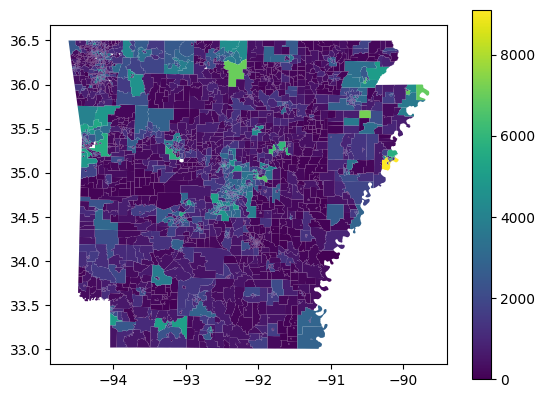

In [40]:
ar_precincts.plot('cvap_total', legend=True)

### Exports

#### To Seawulf

In [41]:
final = ar_precincts.rename(columns={
    "name"           : "Unique_ID",
    "votes_dem"      : "Kamala D. Harris",
    "votes_rep"      : "Donald J. Trump",
    "votes_other"    : "Other_candidates",
    "votes_total"    : "Total_votes",
    "cvap_white"     : "White_population",
    "cvap_black"     : "Black_population",
    "cvap_hispanic"  : "Latino_population",
    "cvap_other"     : "Other_population",
    "cvap_total"     : "Total_population",
    "geometry"       : "geometry"
})

final = final.drop(columns=['share_white', 'share_black', 'share_hispanic', 'share_other'])
final

,Unique_ID,Kamala D. Harris,Donald J. Trump,Other_candidates,Total_votes,White_population,Black_population,Latino_population,Other_population,Total_population,geometry
0,05001-81 - Stuttgart 2,293,639,19,951,1418,557,61,7,2043,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,05001-36 - Gillett Ward 3,25,39,2,66,80,10,1,2,94,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,05001-53 - Dewitt 2,49,188,5,242,441,103,6,5,554,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,05001-51 - DeWitt 1,101,61,5,167,178,66,0,3,247,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,05001-55 - Dewitt 3,42,272,3,317,578,134,7,6,726,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,59,93,5,157,106,12,30,10,157,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,05149-18 - Magazine 1,79,354,7,440,676,0,43,41,760,"POLYGON ((-93.27993 35.21256, -93.2806 35.2125..."
2678,05149-29 - Ions Creek,0,19,0,19,19,0,1,1,21,"POLYGON ((-93.70875 34.83304, -93.70875 34.833..."
2679,05149-24 - Waveland,18,69,1,88,176,2,6,11,196,"POLYGON ((-93.59987 35.14713, -93.60034 35.147..."


In [42]:
final.to_file("../output/Arkansas/seawulf.gpkg", driver="GPKG")

#### To Application

In [43]:
ar_precincts

,name,votes_dem,votes_rep,votes_other,votes_total,cvap_white,cvap_black,cvap_hispanic,cvap_other,cvap_total,share_white,share_black,share_hispanic,share_other,geometry
0,05001-81 - Stuttgart 2,293,639,19,951,1418,557,61,7,2043,0.694077,0.272638,0.029858,0.003426,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,05001-36 - Gillett Ward 3,25,39,2,66,80,10,1,2,94,0.851064,0.106383,0.010638,0.021277,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,05001-53 - Dewitt 2,49,188,5,242,441,103,6,5,554,0.796029,0.185921,0.010830,0.009025,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,05001-51 - DeWitt 1,101,61,5,167,178,66,0,3,247,0.720648,0.267206,0.000000,0.012146,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,05001-55 - Dewitt 3,42,272,3,317,578,134,7,6,726,0.796143,0.184573,0.009642,0.008264,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,59,93,5,157,106,12,30,10,157,0.675159,0.076433,0.191083,0.063694,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,05149-18 - Magazine 1,79,354,7,440,676,0,43,41,760,0.889474,0.000000,0.056579,0.053947,"POLYGON ((-93.27993 35.21256, -93.2806 35.2125..."
2678,05149-29 - Ions Creek,0,19,0,19,19,0,1,1,21,0.904762,0.000000,0.047619,0.047619,"POLYGON ((-93.70875 34.83304, -93.70875 34.833..."
2679,05149-24 - Waveland,18,69,1,88,176,2,6,11,196,0.897959,0.010204,0.030612,0.056122,"POLYGON ((-93.59987 35.14713, -93.60034 35.147..."


In [44]:
precincts = ar_precincts[['name', 'cvap_total',
       'share_black', 'share_hispanic', 'share_other',
       'geometry']]
precincts['GEOID'] = precincts['name']
precincts['share_black'] = precincts['share_black'] * 100
precincts['share_hispanic'] = precincts['share_hispanic'] * 100
precincts['share_other'] = precincts['share_other'] * 100
precincts = precincts[['GEOID', 'name', 'cvap_total',
       'share_black', 'share_hispanic', 'share_other',
       'geometry']]
precincts

,GEOID,name,cvap_total,share_black,share_hispanic,share_other,geometry
0,05001-81 - Stuttgart 2,05001-81 - Stuttgart 2,2043,27.263828,2.985805,0.342633,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,05001-36 - Gillett Ward 3,05001-36 - Gillett Ward 3,94,10.638298,1.063830,2.127660,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,05001-53 - Dewitt 2,05001-53 - Dewitt 2,554,18.592058,1.083032,0.902527,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,05001-51 - DeWitt 1,05001-51 - DeWitt 1,247,26.720648,0.000000,1.214575,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,05001-55 - Dewitt 3,05001-55 - Dewitt 3,726,18.457300,0.964187,0.826446,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,05149-10 - Dardanelle Ward 3,157,7.643312,19.108280,6.369427,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,05149-18 - Magazine 1,05149-18 - Magazine 1,760,0.000000,5.657895,5.394737,"POLYGON ((-93.27993 35.21256, -93.2806 35.2125..."
2678,05149-29 - Ions Creek,05149-29 - Ions Creek,21,0.000000,4.761905,4.761905,"POLYGON ((-93.70875 34.83304, -93.70875 34.833..."
2679,05149-24 - Waveland,05149-24 - Waveland,196,1.020408,3.061224,5.612245,"POLYGON ((-93.59987 35.14713, -93.60034 35.147..."


In [45]:
cols = {
    'GEOID' : 'GEOID',
    'name' : 'precinct', 
    'cvap_total' : 'total_population',
    'share_black' : 'black_percentage', 
    'share_hispanic' : 'latino_percentage', 
    'share_other' : 'other_percentage',
}

precincts = precincts.rename(columns=cols)
precincts

,GEOID,precinct,total_population,black_percentage,latino_percentage,other_percentage,geometry
0,05001-81 - Stuttgart 2,05001-81 - Stuttgart 2,2043,27.263828,2.985805,0.342633,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,05001-36 - Gillett Ward 3,05001-36 - Gillett Ward 3,94,10.638298,1.063830,2.127660,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,05001-53 - Dewitt 2,05001-53 - Dewitt 2,554,18.592058,1.083032,0.902527,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,05001-51 - DeWitt 1,05001-51 - DeWitt 1,247,26.720648,0.000000,1.214575,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,05001-55 - Dewitt 3,05001-55 - Dewitt 3,726,18.457300,0.964187,0.826446,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,05149-10 - Dardanelle Ward 3,157,7.643312,19.108280,6.369427,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,05149-18 - Magazine 1,05149-18 - Magazine 1,760,0.000000,5.657895,5.394737,"POLYGON ((-93.27993 35.21256, -93.2806 35.2125..."
2678,05149-29 - Ions Creek,05149-29 - Ions Creek,21,0.000000,4.761905,4.761905,"POLYGON ((-93.70875 34.83304, -93.70875 34.833..."
2679,05149-24 - Waveland,05149-24 - Waveland,196,1.020408,3.061224,5.612245,"POLYGON ((-93.59987 35.14713, -93.60034 35.147..."


<Axes: >

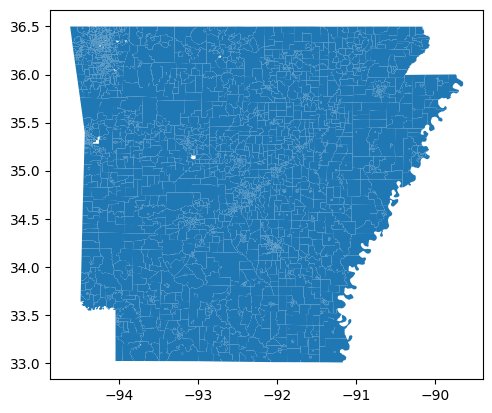

In [46]:
precincts.plot(None)

In [47]:
precincts = precincts.to_crs(epsg=4326)
topo = tp.Topology(precincts)

topo.to_json("../output/Arkansas/Arkansas_precincts_topo.topojson")

<Axes: >

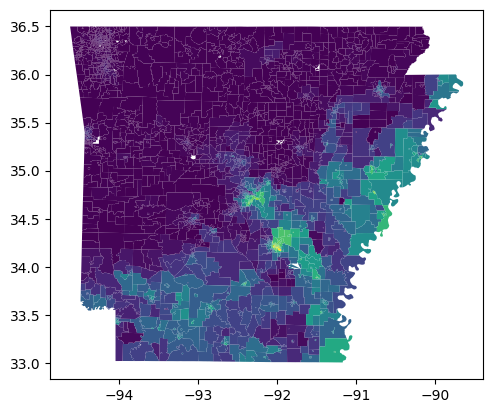

In [48]:
gdf = topo.to_gdf() 
gdf.plot("black_percentage")